# РК1 Алешечкина Марина ИУ5-61Б Вариант 1

### 1. Загрузим данные Iris

In [8]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

### 2. Проверим пропуски

In [9]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


В Iris нет пропусков — удалять ничего не требуется.
Если бы были — удаляем строки (df.dropna()) или колонки (df.dropna(axis=1)).

### 3. Корреляционный анализ

#### Матрица корреляции (только числовые признаки)

In [10]:
corr = df.drop('target', axis=1).corr()
print(corr)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


#### Тепловая карта

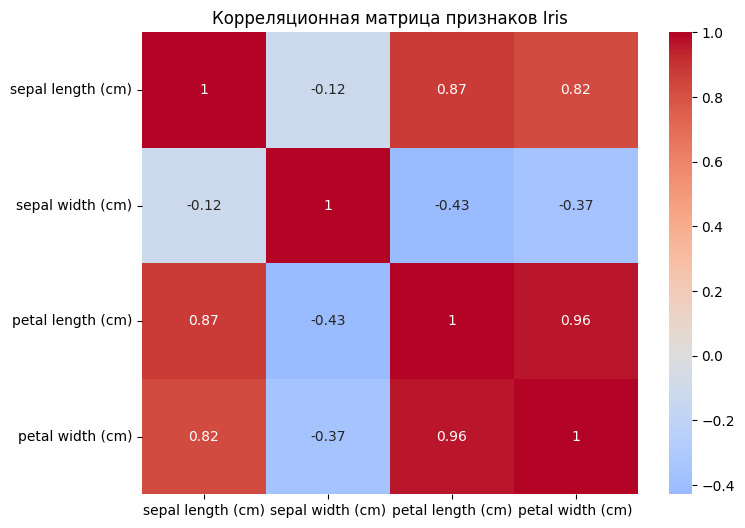

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков Iris')
plt.show()

#### Анализ корреляции с целевой переменной (если задача регрессионная/классификационная)

In [12]:
print(df.corr()['target'].sort_values(ascending=False))

target               1.000000
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: target, dtype: float64


### 4. Выводы

- Наиболее значимые признаки для предсказания вида ириса — petal width (0.9565) и petal length (0.9490). Они имеют очень сильную положительную корреляцию с целевой переменной.
- Признак sepal width имеет умеренную отрицательную корреляцию (-0.4267), что указывает на обратную зависимость: увеличение ширины чашелистика снижает вероятность принадлежности к видам с более высоким индексом (versicolor, virginica).
- Мультиколлинеарность: признаки petal width и petal length сильно коррелированы между собой (≈0.96), что может негативно сказаться на устойчивости линейных моделей.

Рекомендации по выбору моделей:
- Для линейных моделей (логистическая регрессия) рекомендуется исключить один из двух сильно коррелированных признаков или применить L1-регуляризацию (Lasso).
- Деревья решений, случайный лес и градиентный бустинг позволят использовать все признаки без дополнительной обработки.
Все 4 признака вносят вклад в модель, но основной вклад дают petal width и petal length.

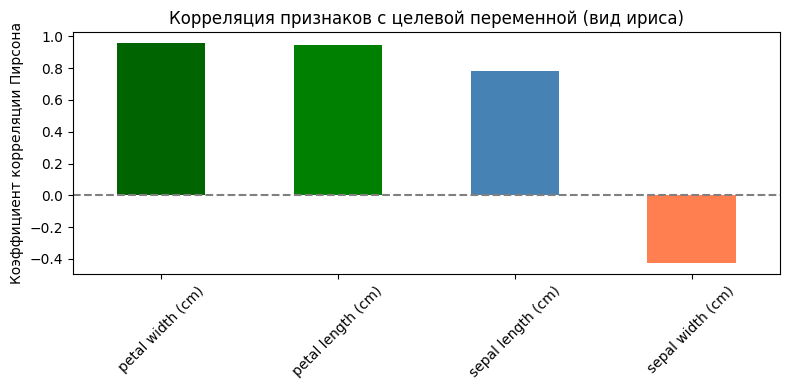

In [13]:
    # График корреляции признаков с target
corr_with_target = df.corr()['target'].sort_values(ascending=False)
plt.figure(figsize=(8,4))
corr_with_target.drop('target').plot(kind='bar', color=['darkgreen', 'green', 'steelblue', 'coral'])
plt.title('Корреляция признаков с целевой переменной (вид ириса)')
plt.ylabel('Коэффициент корреляции Пирсона')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()